In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# generate a random set of bids
N = 2000 # number of agents
M = 24*12*7 # history length (e.g., 1 day of 5 minute auctions)
P = np.random.normal(50,10,N).clip(0,1000)
Q = np.random.normal(0,10,N).clip(-20,20)
Q0 = N/500
id = np.random.randint(2**20,2**21,N)

In [3]:
# generate the supply and demand curves
B = pd.DataFrame(dict(price=P.round(4),quantity=Q.round()/1000),[hex(x)[2:] for x in id])
buy = B[Q>0].sort_values(by="price",ascending=False)
buy["quantity"][buy["quantity"]<0.001] = 0.001
buy["demand"] = buy.quantity.cumsum() + Q0
sell = B[Q<0].sort_values(by="price",ascending=True)
sell["price"][0] = 0.0
sell["quantity"][0] = -Q0/2 # solar
sell["quantity"][int(N/6)] = -Q0/2 # feeder
sell["quantity"][sell["quantity"]>-0.001] = -0.001
sell["supply"] = -sell.quantity.cumsum()

In [4]:
# generate a random history of auctions
P = np.hstack([np.random.normal(P.mean(),P.std()/5,288).clip(P.min(),P.max()),
               np.random.normal(P.mean(),P.std(),M-288).clip(P.min(),P.max())])
Q = np.hstack([np.random.normal(abs(Q).cumsum().mean()/2,abs(Q).cumsum().std()/10,288).clip(0,max(Q[Q>0].sum(),-Q[Q<0].sum())) + Q0,
               np.random.normal(abs(Q).cumsum().mean()/2,abs(Q).cumsum().std()/3,M-288).clip(0,max(Q[Q>0].sum(),-Q[Q<0].sum())) + Q0])

In [5]:
# generate a random clearing history
C = pd.DataFrame(dict(price=P.round(4),quantity=Q.round()/1000+Q0),columns=['price','quantity'])

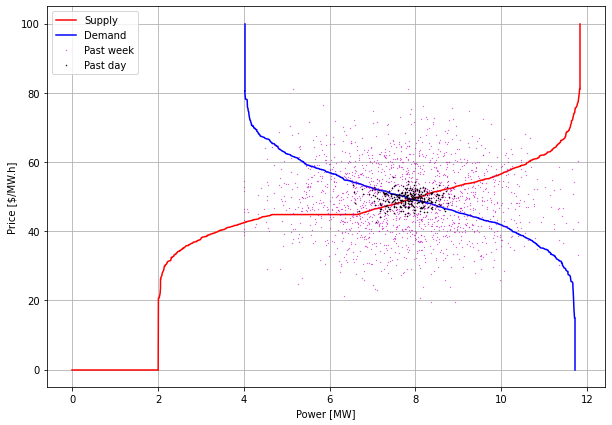

In [24]:
# plot auction
plt.figure(figsize=(10,7))

plt.plot(sell.supply,sell.price,"-r",label="Supply")
plt.plot([0,-sell.quantity[0],-sell.quantity[0]],[0,0,sell.price[0]],"-r")
plt.plot([sell.supply[-1],sell.supply[-1]],[sell.price[-1],100.0],"-r")

plt.plot(buy.demand,buy.price,"-b",label="Demand")
plt.plot([buy.demand[0],buy.demand[0]],[buy.price[0],100],"-b")
plt.plot([buy.demand[-1],buy.demand[-1]],[buy.price[-1],0],"-b")

plt.plot(C.quantity,C.price,".m",markersize=0.5,label="Past week")
plt.plot(C.quantity[:288],C.price[:288],".k",markersize=1,label="Past day")

#plt.xlim([0,N/150])
plt.grid()
plt.xlabel("Power [MW]")
plt.ylabel("Price [$/MW.h]")
plt.legend();

In [7]:
buyers = buy.copy()
buyers.columns = ["Price [$/MW.h]","Quantity [MW]","Dispatch [MW]"]
buyers.index.names = ["Buyer"]
buyers

,Price [$/MW.h],Quantity [MW],Dispatch [MW]
Buyer,,,
107f65,80.5866,0.020,4.020
108d27,78.1603,0.016,4.036
1c75bb,78.1131,0.020,4.056
18656a,77.9909,0.020,4.076
1f59b7,75.7570,0.008,4.084
...,...,...,...
190793,23.9608,0.001,11.676
12a80a,21.5636,0.011,11.687
199966,18.3475,0.009,11.696


In [8]:
buyers_csv = buy.copy()
buyers_csv.columns = ['price','quantity','dispatch']
buyers_csv.index.names = ['bid_id']
buyers_csv.to_csv('buyers.csv')

In [9]:
sellers = sell.copy()
sellers['quantity'] = -sellers.quantity
sellers.columns = ["Price [$/MW.h]","Quantity [MW]","Dispatch [MW]"]
sellers.index.names = ["Seller"]
sellers

,Price [$/MW.h],Quantity [MW],Dispatch [MW]
Seller,,,
17c786,0.0000,2.000,2.000
1f4cb5,20.6024,0.006,2.006
10b470,20.6763,0.014,2.020
1bf3a3,20.7700,0.005,2.025
1a997d,21.9813,0.020,2.045
...,...,...,...
1e9f5d,76.7519,0.004,11.778
1aec30,77.3231,0.020,11.798
1ed23f,78.1722,0.009,11.807


In [10]:
sellers_csv = sell.copy()
sellers_csv.columns = ['price','quantity','dispatch']
sellers_csv['quantity'] = -sellers_csv.quantity
sellers_csv.index.names = ['bid_id']
sellers_csv.to_csv('sellers.csv')

In [11]:
clear = C.copy()
clear.columns = ["Price [$/MW.h]","Power [MW]"]
clear[:24]
import datetime
clear.index = pd.DatetimeIndex([datetime.datetime(year=2022,month=8,day=17,hour=12)+datetime.timedelta(minutes=x*5) for x in range(len(clear))])
clear

,Price [$/MW.h],Power [MW]
2022-08-17 12:00:00,49.6569,8.362
2022-08-17 12:05:00,48.1777,8.334
2022-08-17 12:10:00,50.5962,8.514
2022-08-17 12:15:00,45.6822,7.340
2022-08-17 12:20:00,51.9628,8.094
...,...,...
2022-08-24 11:35:00,63.6006,5.314
2022-08-24 11:40:00,48.0327,8.735
2022-08-24 11:45:00,56.5268,7.849
2022-08-24 11:50:00,51.4261,7.051


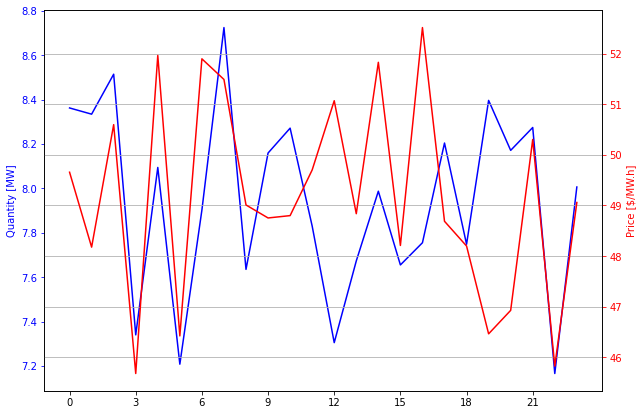

In [12]:
fig,left = plt.subplots(figsize=(10,7))

left.plot(C.quantity[:24],color='blue')
left.set_ylabel('Quantity [MW]',color='blue')
left.tick_params(axis='y',color='blue',labelcolor='blue')

right = left.twinx()
right.plot(C.price[:24],color='red')
right.set_ylabel('Price [$/MW.h]',color='red')
right.tick_params(axis='y',color='red',labelcolor='red')

plt.xticks(range(0,24,3))
plt.grid(axis='both',which='both')

In [13]:
clear.columns = ['price','quantity']
clear.index.names = ['bid_id']
clear.to_csv('clearing.csv')

In [18]:
import logging
def clear_auction(buyers,sellers,unresponsive_demand=0.0):
    
    tic = datetime.datetime.now().timestamp()

    if len(buyers) == 0 or len(sellers) == 0:
        toc = datetime.datetime.now().timestamp()
        return dict(price=float('nan'), dispatch=float('nan'), marginal_unit=None, bid_id=None, unit_quantity=float('nan'), bid_rank=None, clearing_timer=round(toc-tic,6))
    
    # check inputs
    bad_buyers = buyers[buyers.quantity<=0]
    if len(bad_buyers) > 0:
        raise Exception(f"{len(bad_buyers)} invalid quantity for bid ids: {','.join(bad_buyers.index)}")
    bad_sellers = sellers[sellers.quantity<=0]
    if len(bad_sellers) > 0:
        raise Exception(f"{len(bad_sellers)} invalid quantity for bid ids: {','.join(bad_sellers.index)}")

    # prepare buyers
    buyers.sort_values(by="price",ascending=False,inplace=True)
    buyers["dispatch"] = buyers.quantity.cumsum() + unresponsive_demand    
    buyers.sort_values('price',ascending=False,inplace=True)
    logging.debug(f"{len(buyers)} buyers, total quantity={buyers.dispatch[0]:.1f} MW")
   
    # prepare sellers
    sellers.sort_values(by="price",ascending=True,inplace=True)
    sellers["dispatch"] = sellers.quantity.cumsum()    
    sellers.sort_values('price',ascending=True,inplace=True)
    logging.debug(f"{len(sellers)} sellers, total quantity={sellers.dispatch[-1]:.1f} MW")

    # find clearing price and quantity
    n_buyers = len(buyers)
    n_sellers = len(sellers)
    i = 0
    j = 0
    check = 0
    bid = None
    unit = None
    margin = None
    rank = None
    while i < n_buyers and j < n_sellers:
        buy = buyers.iloc[i]
        sell = sellers.iloc[j]
        logging.debug(f"buyer[{i}]:  {buy.to_json()}")
        logging.debug(f"seller[{j}]: {sell.to_json()}")
        if buy.price < sell.price:
            logging.debug(f"{buy.price} < {sell.price} --> done")
            break
        elif buy.dispatch > sell.dispatch:
            dispatch = sell.dispatch
            a = b = buy.price
            j += 1
            check = 0
            bid = buyers.index[i]
            unit = buy
            margin = 'buyer'
            rank = i
        elif buy.dispatch < sell.dispatch:
            dispatch = buy.dispatch
            a = b = sell.price
            i += 1
            check = 0
            bid = sellers.index[j]
            unit = sell
            margin = 'seller'
            rank = j
        else:
            dispatch = buy.dispatch
            a = buy.price
            b = sell.price
            i += 1
            j += 1
            check = 1
    while check == 1:
        buy = buyers.iloc[i]
        sell = sellers.iloc[j]
        if i > 0 and i < n_buyers and (a+b)/2 <= buy.price:
            b = buy.price
            bid = buyers.index[i]
            unit = buy
            margin = 'buyer'
            rank = i
            i += 1
        elif j > 0 and j < n_sellers and (a+b)/2 <= sell.price:
            a = sell.price
            bid = sellers.index[j]
            unit = sell
            margin = 'seller'
            j += 1
            rank = j
        else:
            check = 0
    price = (a+b)/2
    quantity = unit.dispatch - dispatch
    logging.debug(f"clearing price = {price:.2f} $/MWh, quantity = {dispatch:.1f} MW")

    toc = datetime.datetime.now().timestamp()
    return dict(price=round(price,2), dispatch=round(dispatch,3), marginal_unit=margin, bid_id=bid, unit_quantity=round(quantity,3), bid_rank=rank, clearing_timer=round(toc-tic,6))


In [15]:
logging.basicConfig(filename="/dev/stderr", level=logging.WARNING, encoding='utf-8')
result = clear_auction(buyers_csv,sellers_csv,2.0)
print("Market clear ok for",result)

if result["marginal_unit"] == 'seller':
    print("Marginal unit",result["bid_id"],"clears at",sellers_csv.loc[result["bid_id"]].to_json())
elif result["marginal_unit"] == 'buyer':
    print("Marginal unit",result["bid_id"],"clears at",buyers_csv.loc[result["bid_id"]].to_json())

print("")
buyers_on = buyers_csv[buyers_csv.price>result["price"]].copy()
buyers_on["surplus"] = (buyers_on.price-result["price"])*buyers_on.quantity
buyers_surplus = buyers_on.surplus.sum()
print(f"Buyers surplus:  ${buyers_surplus:10.2f}")

sellers_on = sellers_csv[sellers_csv.price<result["price"]].copy()
sellers_on["surplus"] = -(sellers_on.price-result["price"])*sellers_on.quantity
sellers_surplus = sellers_on.surplus.sum()
print(f"Sellers surplus: ${sellers_surplus:10.2f}")

print(f"                 -----------")
print(f"Total surplus:   ${sellers_surplus+buyers_surplus:10.2f}")



Market clear ok for {'price': 45.76, 'dispatch': 6.914, 'marginal_unit': 'seller', 'bid_id': '17097c', 'unit_quantity': 0.0, 'bid_rank': 367, 'clearing_timer': 0.165085}
Marginal unit 17097c clears at {"price":45.7628,"quantity":0.011,"dispatch":6.914}

Buyers surplus:  $     50.95
Sellers surplus: $    112.85
                 -----------
Total surplus:   $    163.80


In [19]:
empty = pd.DataFrame(dict(quantity=[],price=[]))
clear_auction(empty,empty)

{'price': nan,
 'dispatch': nan,
 'marginal_unit': None,
 'bid_id': None,
 'unit_quantity': nan,
 'bid_rank': None,
 'clearing_timer': 1e-05}